In [1]:
!pip install tensorflow tensorflow-datasets matplotlib opencv-python-headless

In [2]:
!pip install opendatasets

In [3]:
!pip install numpy opencv-python Pillow

In [4]:
import opendatasets as od
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from shutil import move
import shutil
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, Resizing

In [5]:
#Load the data from kaggle
video_path = "https://www.kaggle.com/datasets/soumicksarker/multiple-cameras-fall-dataset"

{"username":"ibebenedict","key":"f9402928d7dce1078c5310e48dfb2874"}

In [6]:
od.download(video_path)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ibebenedict
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/soumicksarker/multiple-cameras-fall-dataset


100%|██████████| 3.52G/3.52G [00:10<00:00, 359MB/s]


In [7]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 61.0 MB/s eta 0:00:00


In [8]:
import cv2
import pandas as pd
import os
import shutil
from ultralytics import YOLO
from tqdm import tqdm

# --- CONFIGURATION ---
# 1. Ensure this matches your screenshot path exactly
VIDEO_ROOT_DIR = '/content/multiple-cameras-fall-dataset/dataset/dataset'
CSV_PATH = 'data_tuple3.csv'
OUTPUT_DIR = 'Fall_Detection_Dataset'

# 2. Create YOLO directory structure
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR) # Clean up if it exists to avoid duplicates

for split in ['train', 'val']:
    os.makedirs(f"{OUTPUT_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{OUTPUT_DIR}/labels/{split}", exist_ok=True)

# 3. Load YOLOv10n
# Ideally use 'yolov10n.pt' if you have the weights, otherwise 'yolov8n.pt' works fine as a person detector
try:
    model = YOLO('yolov10n.pt')
except:
    print("YOLOv10 weights not found, downloading/using YOLOv8n as fallback...")
    model = YOLO('yolov8n.pt')

# 4. Load Annotations
df = pd.read_csv(CSV_PATH)

def process_dataset():
    print(f"Processing {len(df)} clips...")

    # Loop through each annotation row
    for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Processing Clips"):
        try:
            # Parse CSV row
            chute = int(row['chute'])
            cam = int(row['cam'])
            start_frame = int(row['start'])
            end_frame = int(row['end'])
            label_class = int(row['label']) # 0 (No Fall) or 1 (Fall)

            # --- PATH CONSTRUCTION ---
            # Matches your screenshot: chute01, chute02...
            folder_name = f"chute{chute:02d}"

            # Check for .avi or .mp4
            video_path_avi = os.path.join(VIDEO_ROOT_DIR, folder_name, f"cam{cam}.avi")
            video_path_mp4 = os.path.join(VIDEO_ROOT_DIR, folder_name, f"cam{cam}.mp4")

            if os.path.exists(video_path_avi):
                video_path = video_path_avi
            elif os.path.exists(video_path_mp4):
                video_path = video_path_mp4
            else:
                # DEBUG: Uncomment this if you suspect path issues
                # print(f"Skipping: File not found at {video_path_avi}")
                continue

            cap = cv2.VideoCapture(video_path)

            # Go to the start frame
            cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
            current_frame = start_frame

            while current_frame <= end_frame:
                ret, frame = cap.read()
                if not ret:
                    break

                # --- YOLO AUTO-ANNOTATION ---
                # We use YOLO to finding the person (Class 0), but we assign the CSV label (Fall/No Fall)
                results = model(frame, classes=[0], verbose=False)

                # Only save if a person is detected
                if len(results[0].boxes) > 0:
                    # Pick the person with highest confidence
                    box = results[0].boxes[0]
                    x_center, y_center, width, height = box.xywhn[0].tolist()

                    # Generate unique filename
                    base_name = f"chute{chute}_cam{cam}_frame{current_frame}"

                    # Determine split (80% Train, 20% Val)
                    split = 'val' if index % 5 == 0 else 'train'

                    # 1. Save Image
                    img_name = f"{base_name}.jpg"
                    cv2.imwrite(f"{OUTPUT_DIR}/images/{split}/{img_name}", frame)

                    # 2. Save Label (YOLO Format: class x_c y_c w h)
                    # CRITICAL: We write 'label_class' (0 or 1 from CSV) not the class detected by YOLO
                    label_name = f"{base_name}.txt"
                    with open(f"{OUTPUT_DIR}/labels/{split}/{label_name}", 'w') as f:
                        f.write(f"{label_class} {x_center} {y_center} {width} {height}")

                current_frame += 1

            cap.release()

        except Exception as e:
            print(f"Error processing row {index}: {e}")

    print("\nDataset generation complete!")
    print(f"Files saved in: {OUTPUT_DIR}")

# Run the processing
if __name__ == "__main__":
    process_dataset()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Processing 552 clips...


Processing Clips: 100%|██████████| 552/552 [03:50<00:00,  2.39it/s]


Dataset generation complete!
Files saved in: Fall_Detection_Dataset


In [9]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLO12n model
model = YOLO("yolo12n.pt")

In [21]:
import yaml
import os
from ultralytics import YOLO

# --- STEP 1: Generate data.yaml ---
# We need to tell YOLO where the dataset is and what the classes are.
yaml_content = {
    'path': os.path.abspath(OUTPUT_DIR), # Absolute path to your dataset folder
    'train': 'images/train',             # Train images (relative to 'path')
    'val': 'images/val',                 # Val images (relative to 'path')
    'names': {                           # Class names
        0: 'No Fall',
        1: 'Fall'
    }
}

yaml_path = os.path.join(OUTPUT_DIR, 'data.yaml')

with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

print(f"Successfully created data config at: {yaml_path}")
print(f"Classes defined: {yaml_content['names']}")

# --- STEP 2: Train the Model ---
# Note: 'yolov12n' does not exist yet. The latest official versions are v8, v10, and v11.
# We will use YOLOv10n as per your pipeline request.
# If you specifically want the absolute latest, change to 'yolo11n.pt'.

print("Starting Training...")

try:
    # Load the model (it will download weights if not found)
    model = YOLO('/content/yolo11l.pt')

    # Run Training
    results = model.train(
        data=yaml_path,   # Path to the yaml we just created
        epochs=20,        # 20 is good for testing, try 50-100 for final paper
        imgsz=672,        # Standard image size
        batch=16,         # Adjust if you run out of GPU memory
        name='fall_detection_experiment' # Name of the run folder
    )

    print("Training Complete!")
    print(f"Best model saved at: {results.save_dir}/weights/best.pt")

except Exception as e:
    print(f"Error during training: {e}")
    print("Tip: If 'yolov11l.pt' fails to download, try using 'yolov8n.pt' or 'yolo11n.pt' instead.")

Successfully created data config at: Fall_Detection_Dataset/data.yaml
Classes defined: {0: 'No Fall', 1: 'Fall'}
Starting Training...
Ultralytics 8.3.229 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Fall_Detection_Dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=672, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolo11l.pt, momentum=0.937, mosaic=1.0, mu

In [22]:
from ultralytics import YOLO
import os

# --- CONFIGURATION ---
# 1. Path to the data config you created earlier
OUTPUT_DIR = 'Fall_Detection_Dataset'
yaml_path = os.path.join(OUTPUT_DIR, 'data.yaml')

# 2. Path to the 'best.pt' model saved after training
# Based on your training code: name='fall_detection_experiment'
model_path = '/content/runs/detect/fall_detection_experiment3/weights/best.pt'

print(f"Looking for model at: {model_path}")

if os.path.exists(model_path):
    # --- LOAD MODEL ---
    # We load the fine-tuned weights, NOT the original 'yolo12m.pt'
    model = YOLO(model_path)

    # --- RUN VALIDATION ---
    # This runs the model on the images defined in 'val' in data.yaml
    print("Starting Validation...")
    metrics = model.val(data=yaml_path, split='val')

    # --- DISPLAY RESULTS ---
    print("\n" + "="*30)
    print("   VALIDATION METRICS")
    print("="*30)
    print(f"mAP@50:      {metrics.box.map50:.4f}  <-- Primary Metric (Standard)")
    print(f"mAP@50-95:   {metrics.box.map:.4f}    <-- Strict Metric (High Precision)")
    print(f"Precision:   {metrics.box.mp:.4f}")
    print(f"Recall:      {metrics.box.mr:.4f}")
    print("="*30)

    print(f"\nDetailed graphs (Confusion Matrix, F1-Curve) saved in: {metrics.save_dir}")

else:
    print(f"ERROR: Could not find model at {model_path}")
    print("Please check your 'runs/detect' folder. If you ran training multiple times,")
    print("it might be in 'fall_detection_experiment2', 'fall_detection_experiment3', etc.")

Looking for model at: /content/runs/detect/fall_detection_experiment3/weights/best.pt
Starting Validation...
Ultralytics 8.3.229 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLO11l summary (fused): 190 layers, 25,280,854 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2364.0±1113.4 MB/s, size: 111.6 KB)
val: Scanning /content/Fall_Detection_Dataset/labels/val.cache... 2254 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2254/2254 5.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 141/141 10.1it/s 14.0s
                   all       2254       2254      0.679      0.849      0.794      0.648
               No Fall       1218       1218      0.687       0.88      0.819        0.7
                  Fall       1036       1036      0.672      0.818      0.769      0.596
Speed: 0.5ms preprocess, 2.7ms inference, 0.0ms loss, 0.7ms postprocess per ima

In [11]:
!pip install deep-sort-realtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 97.1 MB/s eta 0:00:00


Processing video: /content/multiple-cameras-fall-dataset/dataset/dataset/chute01/cam1.avi...
Video processing complete. Saved to fall_detection_result.avi


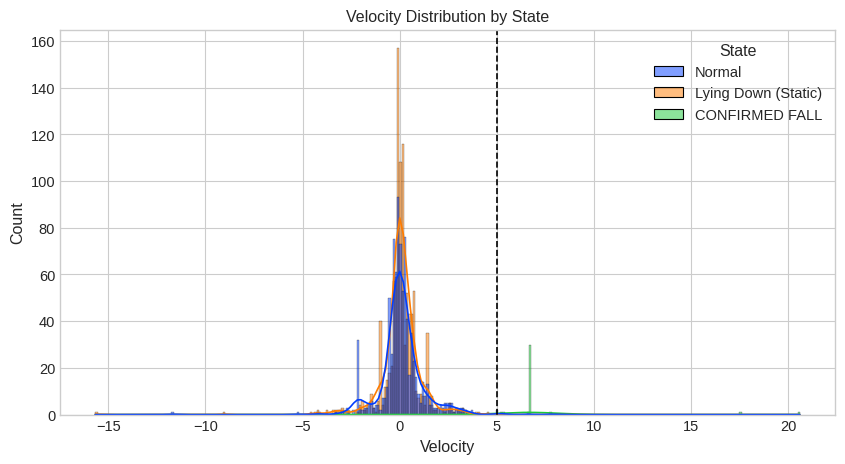

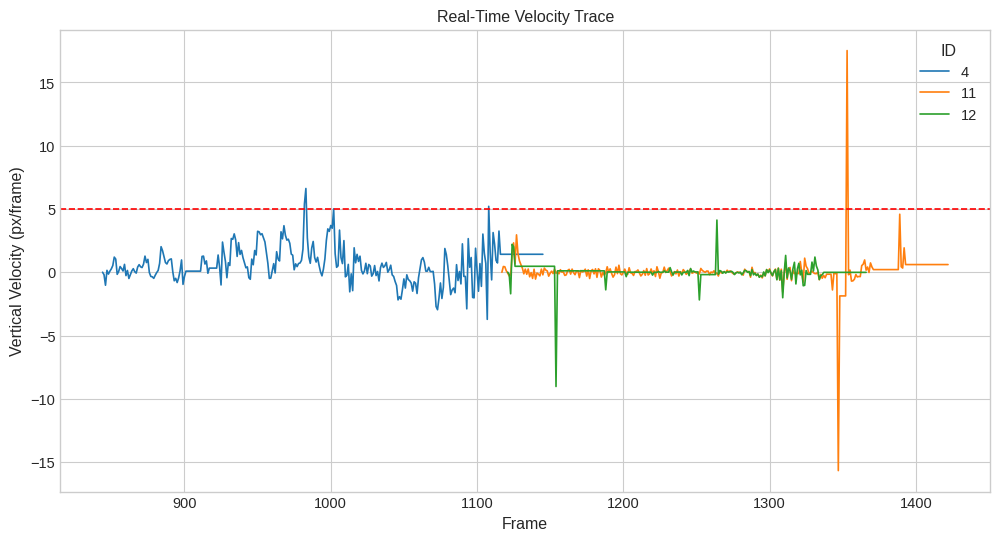

Graphs generated and saved.


In [23]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort
import os

# --- CONFIGURATION ---
# 1. Locate your trained model
# If you just finished training, it's likely here:
TRAINED_MODEL_PATH = '/content/runs/detect/fall_detection_experiment3/weights/best.pt'

# 2. Select a video to test
# Replace this with an actual path from your dataset!
VIDEO_SOURCE = '/content/multiple-cameras-fall-dataset/dataset/dataset/chute01/cam1.avi'
OUTPUT_VIDEO = 'fall_detection_result.avi'

# 3. Physics Parameters
VELOCITY_THRESHOLD = 5.0 # Pixels/frame. (If video is high-res 1080p, increase to ~15.0)

# --- INITIALIZATION ---
if not os.path.exists(TRAINED_MODEL_PATH):
    print(f"WARNING: Model not found at {TRAINED_MODEL_PATH}. Using 'yolov8n.pt' for demo.")
    TRAINED_MODEL_PATH = 'yolov8n.pt'

model = YOLO(TRAINED_MODEL_PATH)
tracker = DeepSort(max_age=30, n_init=3)

cap = cv2.VideoCapture(VIDEO_SOURCE)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# Setup Video Writer to save result
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (width, height))

# Logging for Graphs
track_history = {}
velocity_log = []
frame_count = 0

print(f"Processing video: {VIDEO_SOURCE}...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    frame_count += 1

    # 1. DETECT (YOLO)
    results = model(frame, verbose=False)
    detections = []

    # Extract boxes for DeepSORT
    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf = float(box.conf[0])
            cls = int(box.cls[0]) # 0 = No Fall, 1 = Fall (based on your training)

            # DeepSORT expects [left, top, w, h]
            w = x2 - x1
            h = y2 - y1

            # We pass the 'cls' as the detection class so we can use it later
            detections.append(([x1, y1, w, h], conf, cls))

    # 2. TRACK (DeepSORT)
    # update_tracks returns tracks with ID
    tracks = tracker.update_tracks(detections, frame=frame)

    for track in tracks:
        if not track.is_confirmed():
            continue

        track_id = track.track_id
        ltrb = track.to_ltrb() # left, top, right, bottom

        # Calculate Centroid
        cx_current = (ltrb[0] + ltrb[2]) / 2
        cy_current = (ltrb[1] + ltrb[3]) / 2

        # 3. CALCULATE PHYSICS (Velocity)
        velocity = 0
        if track_id in track_history:
            prev_cx, prev_cy = track_history[track_id]

            # Vertical Velocity (Positive = Down)
            velocity = cy_current - prev_cy

        track_history[track_id] = (cx_current, cy_current)

        # 4. VALIDATION LOGIC
        # Retrieve the class ID stored in the track detail
        # Note: DeepSort usually stores the class in 'det_class' if passed correctly,
        # but sometimes we need to infer it. Here we assume the track keeps the detection's class.
        try:
            det_class = track.det_class
        except:
            det_class = 0 # Default to 0 if missing

        state = "Normal"
        color = (0, 255, 0) # Green

        # Logic: Only confirm FALL if Model says "Fall" AND Velocity is High
        if det_class == 1: # Model predicts Fall
            if velocity > VELOCITY_THRESHOLD:
                state = "CONFIRMED FALL"
                color = (0, 0, 255) # Red
            else:
                state = "Lying Down (Static)" # False positive correction
                color = (0, 255, 255) # Yellow

        # Log data for plotting
        velocity_log.append({
            'Frame': frame_count,
            'ID': track_id,
            'Velocity': velocity,
            'State': state
        })

        # Draw Bounding Box & Text
        cv2.rectangle(frame, (int(ltrb[0]), int(ltrb[1])), (int(ltrb[2]), int(ltrb[3])), color, 2)
        label = f"ID:{track_id} Vel:{velocity:.1f} {state}"
        cv2.putText(frame, label, (int(ltrb[0]), int(ltrb[1])-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    # Write frame to output video
    out.write(frame)

cap.release()
out.release()
print(f"Video processing complete. Saved to {OUTPUT_VIDEO}")

# --- 5. GENERATE EXPERIMENT GRAPHS ---
if len(velocity_log) > 0:
    df = pd.DataFrame(velocity_log)

    # Setup Plot Style
    sns.set_context("paper", font_scale=1.2)
    plt.style.use('seaborn-v0_8-whitegrid')

    # Graph A: Velocity Histogram
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df, x='Velocity', hue='State', kde=True, palette='bright')
    plt.axvline(VELOCITY_THRESHOLD, color='k', linestyle='--', label='Threshold')
    plt.title('Velocity Distribution by State')
    plt.savefig('exp_velocity_hist.png')
    plt.show()

    # Graph B: Tracking Trace
    plt.figure(figsize=(12, 6))
    # Filter for top 3 IDs to keep graph clean
    top_ids = df['ID'].value_counts().head(3).index
    sns.lineplot(data=df[df['ID'].isin(top_ids)], x='Frame', y='Velocity', hue='ID')
    plt.axhline(VELOCITY_THRESHOLD, color='red', linestyle='--', label='Fall Threshold')
    plt.title('Real-Time Velocity Trace')
    plt.ylabel('Vertical Velocity (px/frame)')
    plt.savefig('exp_velocity_trace.png')
    plt.show()

    print("Graphs generated and saved.")
else:
    print("No tracks detected. Check if video path is correct.")

Testing on he test dataset

In [24]:
import cv2
import numpy as np
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort
import os

# --- CONFIGURATION ---
# 1. Path to your trained model (check the folder name in 'runs/detect/')
# If you ran the training code exactly as before, it should be here:
MODEL_PATH = '/content/runs/detect/fall_detection_experiment3/weights/best.pt'

# 2. Path to the video you want to test
# Replace this with the actual path to one of your chute videos
VIDEO_PATH = '/content/multiple-cameras-fall-dataset/dataset/dataset/chute01/cam1.avi'

# 3. Output filename
OUTPUT_PATH = 'final_test_output.avi'

# 4. Physics Threshold (Adjust if needed)
VELOCITY_THRESH = 5.0

# --- LOAD MODEL & TRACKER ---
print(f"Loading model from: {MODEL_PATH}")
if not os.path.exists(MODEL_PATH):
    print("Error: Model not found! Please check the path.")
    # Fallback for testing code logic only
    # model = YOLO('yolov8n.pt')
else:
    model = YOLO(MODEL_PATH)

tracker = DeepSort(max_age=30, n_init=3)

# --- VIDEO SETUP ---
cap = cv2.VideoCapture(VIDEO_PATH)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# Codec for saving output
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (width, height))

track_history = {} # To store previous centroids

print(f"Processing video: {VIDEO_PATH}")
print("Please wait...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # 1. YOLO Detection
    results = model(frame, verbose=False)
    detections = []

    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf = float(box.conf[0])
            cls = int(box.cls[0]) # 0=NoFall, 1=Fall

            # Only pass if confidence is decent
            if conf > 0.5:
                w = x2 - x1
                h = y2 - y1
                # Pass detection to tracker
                detections.append(([x1, y1, w, h], conf, cls))

    # 2. DeepSORT Tracking
    tracks = tracker.update_tracks(detections, frame=frame)

    for track in tracks:
        if not track.is_confirmed():
            continue

        track_id = track.track_id
        ltrb = track.to_ltrb()

        # Centroid Calculation
        cx = (ltrb[0] + ltrb[2]) / 2
        cy = (ltrb[1] + ltrb[3]) / 2

        # 3. Velocity Logic
        velocity = 0
        if track_id in track_history:
            prev_cx, prev_cy = track_history[track_id]
            velocity = cy - prev_cy # Positive = Down

        track_history[track_id] = (cx, cy)

        # 4. Custom Classification Logic
        # Get the class predicted by YOLO for this track
        try:
            det_class = track.get_det_class()
        except:
            det_class = 0 # Default

        state = "Normal"
        color = (0, 255, 0) # Green

        # IF YOLO says "Fall" AND Velocity is High -> CONFIRMED
        if det_class == 1:
            if velocity > VELOCITY_THRESH:
                state = "FALLING!"
                color = (0, 0, 255) # Red
            else:
                state = "Lying Down" # Detected fall pose, but no motion
                color = (0, 255, 255) # Yellow

        # Draw
        cv2.rectangle(frame, (int(ltrb[0]), int(ltrb[1])), (int(ltrb[2]), int(ltrb[3])), color, 2)
        cv2.putText(frame, f"ID:{track_id} Vel:{velocity:.1f} {state}",
                    (int(ltrb[0]), int(ltrb[1])-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    out.write(frame)

cap.release()
out.release()
print("Done!")
print(f"Video saved as: {OUTPUT_PATH}")

Loading model from: /content/runs/detect/fall_detection_experiment3/weights/best.pt
Processing video: /content/multiple-cameras-fall-dataset/dataset/dataset/chute01/cam1.avi
Please wait...
Done!
Video saved as: final_test_output.avi


Processing video... looking for 'FALLING!' event.
✅ FALL DETECTED! Snapshot saved as: confirmed_fall_frame_1101.jpg

--- FALL CONFIRMATION FRAME ---


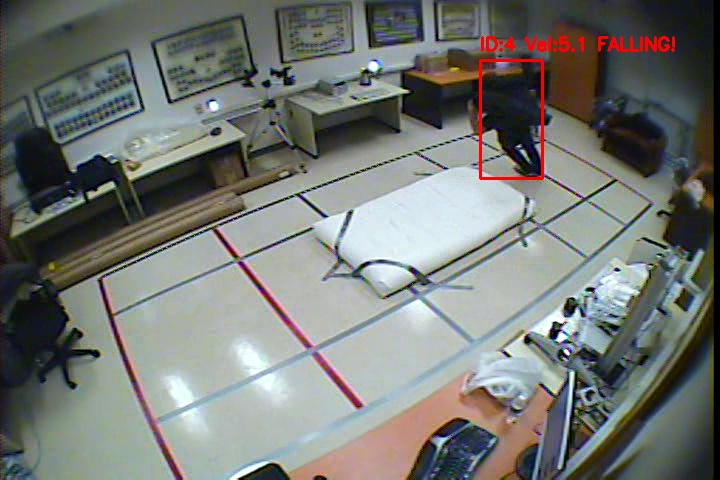

In [26]:
import cv2
import numpy as np
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort
import os
from IPython.display import Image, display

# --- CONFIGURATION ---
MODEL_PATH = '/content/runs/detect/fall_detection_experiment3/weights/best.pt'
VIDEO_PATH = '/content/multiple-cameras-fall-dataset/dataset/dataset/chute01/cam3.avi'
OUTPUT_PATH = 'final_test_output.avi'
VELOCITY_THRESH = 5.0

# Load Model & Tracker
model = YOLO(MODEL_PATH)
tracker = DeepSort(max_age=30, n_init=3)

# Video Setup
cap = cv2.VideoCapture(VIDEO_PATH)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (width, height))

track_history = {}
snapshot_saved = False
saved_snapshot_name = None # <--- NEW VARIABLE TO STORE THE FILENAME

print(f"Processing video... looking for 'FALLING!' event.")

frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    frame_count += 1

    # 1. YOLO Detection
    results = model(frame, verbose=False)
    detections = []
    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf = float(box.conf[0])
            cls = int(box.cls[0])
            if conf > 0.5:
                w = x2 - x1
                h = y2 - y1
                detections.append(([x1, y1, w, h], conf, cls))

    # 2. DeepSORT Tracking
    tracks = tracker.update_tracks(detections, frame=frame)

    for track in tracks:
        if not track.is_confirmed():
            continue

        track_id = track.track_id
        ltrb = track.to_ltrb()
        cx = (ltrb[0] + ltrb[2]) / 2
        cy = (ltrb[1] + ltrb[3]) / 2

        # 3. Velocity Logic
        velocity = 0
        if track_id in track_history:
            prev_cx, prev_cy = track_history[track_id]
            velocity = cy - prev_cy

        track_history[track_id] = (cx, cy)

        # 4. Classification & Labeling
        try:
            det_class = track.get_det_class()
        except:
            det_class = 0

        state = "Normal"
        color = (0, 255, 0) # Green

        if det_class == 1:
            if velocity > VELOCITY_THRESH:
                state = "FALLING!"
                color = (0, 0, 255)    # Red

                # Save the Proof Frame
                if not snapshot_saved:
                    # Draw box explicitly for the screenshot
                    cv2.rectangle(frame, (int(ltrb[0]), int(ltrb[1])), (int(ltrb[2]), int(ltrb[3])), color, 2)
                    cv2.putText(frame, f"ID:{track_id} Vel:{velocity:.1f} {state}",
                                (int(ltrb[0]), int(ltrb[1])-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

                    # Store the filename in a variable so we don't lose it
                    saved_snapshot_name = f"confirmed_fall_frame_{frame_count}.jpg"
                    cv2.imwrite(saved_snapshot_name, frame)

                    print(f"✅ FALL DETECTED! Snapshot saved as: {saved_snapshot_name}")
                    snapshot_saved = True
            else:
                state = "Lying Down"
                color = (0, 255, 255) # Yellow

        # Draw (for video output)
        cv2.rectangle(frame, (int(ltrb[0]), int(ltrb[1])), (int(ltrb[2]), int(ltrb[3])), color, 2)
        cv2.putText(frame, f"ID:{track_id} Vel:{velocity:.1f} {state}",
                    (int(ltrb[0]), int(ltrb[1])-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    out.write(frame)

cap.release()
out.release()

# --- DISPLAY CORRECTED ---
if snapshot_saved and saved_snapshot_name is not None:
    print("\n--- FALL CONFIRMATION FRAME ---")
    # We use the stored filename variable, not the current frame_count
    display(Image(filename=saved_snapshot_name))
else:
    print("No fall confirmed in this video.")

**EVALUATION**

In [27]:
import pandas as pd
import numpy as np
import cv2
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score
import time

# --- CONFIGURATION ---
CSV_PATH = 'data_tuple3.csv'
VIDEO_ROOT = '/content/multiple-cameras-fall-dataset/dataset/dataset'
MODEL_PATH = '/content/runs/detect/fall_detection_experiment3/weights/best.pt'
VELOCITY_THRESH = 5.0

# Load Data & Model
df = pd.read_csv(CSV_PATH)
# Let's use a subset for quick evaluation (e.g., first 20 rows or all 'val' rows)
# For a real paper, use the entire validation set!
eval_df = df.sample(n=20, random_state=42) # Running on 20 random clips for demo
model = YOLO(MODEL_PATH)

y_true = []
y_pred = []
inference_times = []

print(f"Starting Evaluation on {len(eval_df)} clips...")

for index, row in eval_df.iterrows():
    # 1. Setup Video Path
    chute = int(row['chute'])
    cam = int(row['cam'])
    label_gt = int(row['label']) # 0 or 1

    folder_name = f"chute{chute:02d}"
    video_path = f"{VIDEO_ROOT}/{folder_name}/cam{cam}.avi"

    if not os.path.exists(video_path):
        continue

    # 2. Run Inference (Simplified for Speed)
    cap = cv2.VideoCapture(video_path)
    tracker = DeepSort(max_age=30, n_init=3)
    track_history = {}

    max_velocity_detected = 0
    system_predicted_fall = 0 # Default to No Fall

    start_time = time.time()

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # YOLO
        results = model(frame, verbose=False)
        detections = []
        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                conf = float(box.conf[0])
                cls = int(box.cls[0])
                if conf > 0.5:
                    detections.append(([x1, y1, x2-x1, y2-y1], conf, cls))

        # DeepSORT
        tracks = tracker.update_tracks(detections, frame=frame)

        for track in tracks:
            if not track.is_confirmed(): continue

            tid = track.track_id
            ltrb = track.to_ltrb()
            cy = (ltrb[1] + ltrb[3]) / 2

            vel = 0
            if tid in track_history:
                vel = cy - track_history[tid]

            track_history[tid] = cy

            # CHECK ALARM CONDITION
            # If YOLO says Fall (1) AND Velocity > Threshold
            try:
                det_cls = track.get_det_class()
            except:
                det_cls = 0

            if det_cls == 1 and vel > VELOCITY_THRESH:
                system_predicted_fall = 1 # Trigger Alarm

    cap.release()
    end_time = time.time()

    # Log metrics
    y_true.append(label_gt)
    y_pred.append(system_predicted_fall)
    inference_times.append(end_time - start_time)

    print(f"Clip {index}: GT={label_gt}, Pred={system_predicted_fall} [{'CORRECT' if label_gt==system_predicted_fall else 'WRONG'}]")

# --- 3. CALCULATE FINAL METRICS ---
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0) # Sensitivity
f1 = f1_score(y_true, y_pred, zero_division=0)
cm = confusion_matrix(y_true, y_pred)

# Calculate FPS (Average frames / Average time)
# Note: This is a rough estimate based on total clip time
avg_time_per_clip = np.mean(inference_times)
print("\n" + "="*40)
print("       SYSTEM EVALUATION REPORT       ")
print("="*40)
print(f"Total Clips Tested: {len(y_true)}")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}  (Reliability)")
print(f"Recall:      {recall:.4f}  (Safety/Sensitivity)")
print(f"F1-Score:    {f1:.4f}  (Balance)")
print("-" * 40)
print("Confusion Matrix:")
print(f"TN: {cm[0][0]}  FP: {cm[0][1]}")
print(f"FN: {cm[1][0]}  TP: {cm[1][1]}")
print("="*40)

Starting Evaluation on 20 clips...
Clip 547: GT=1, Pred=1 [CORRECT]
Clip 81: GT=0, Pred=1 [WRONG]
Clip 140: GT=0, Pred=1 [WRONG]
Clip 79: GT=0, Pred=1 [WRONG]
Clip 272: GT=1, Pred=1 [CORRECT]
Clip 360: GT=0, Pred=1 [WRONG]
Clip 495: GT=1, Pred=1 [CORRECT]
Clip 479: GT=1, Pred=1 [CORRECT]
Clip 82: GT=1, Pred=1 [CORRECT]
Clip 361: GT=1, Pred=1 [CORRECT]
Clip 185: GT=1, Pred=0 [WRONG]
Clip 10: GT=1, Pred=1 [CORRECT]
Clip 83: GT=0, Pred=1 [WRONG]
Clip 222: GT=0, Pred=0 [CORRECT]
Clip 290: GT=0, Pred=1 [WRONG]
Clip 84: GT=0, Pred=1 [WRONG]
Clip 523: GT=1, Pred=1 [CORRECT]
Clip 6: GT=0, Pred=1 [WRONG]
Clip 346: GT=0, Pred=0 [CORRECT]
Clip 257: GT=1, Pred=1 [CORRECT]

       SYSTEM EVALUATION REPORT       
Total Clips Tested: 20
Accuracy:    0.5500
Precision:   0.5294  (Reliability)
Recall:      0.9000  (Safety/Sensitivity)
F1-Score:    0.6667  (Balance)
----------------------------------------
Confusion Matrix:
TN: 2  FP: 8
FN: 1  TP: 9
